# EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuración de visualización
%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300

In [2]:
# Definición de ruta
file_path = '../../data/raw/dataset_aireado.csv'

if os.path.exists(file_path):
    df_raw = pd.read_csv(file_path)
    print(f"Dataset cargado exitosamente. Formato: {df_raw.shape}")
else:
    print("Error: El archivo no existe en la ruta especificada.")

# Asegurar orden temporal para los lags
df_raw = df_raw.sort_values(['run_id', 'time_min'])
df_raw.head()
#df_raw.isnull().sum()
df_raw.describe()

Dataset cargado exitosamente. Formato: (30000, 11)


,run_id,time_min,T_amb,T_set,fault_id,Kg_embutido,N_fan_Hz,T_cab,RH_cab,T_evap_sat,P_comp_W
count,30000.000000,30000.000000,30000.000000,30000.0,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,149.500000,49.500000,21.999741,14.0,0.600000,843.765979,38.101074,15.126127,75.282899,5.926127,1056.105782
std,86.603503,28.866551,0.998950,0.0,1.019821,382.010798,19.216934,0.547527,14.293359,3.628913,361.030280
min,0.000000,0.000000,18.077600,14.0,0.000000,206.580059,0.000013,13.670653,33.785434,-6.329347,171.881498
25%,74.750000,24.750000,21.323879,14.0,0.000000,510.805045,23.463786,14.672794,69.034207,6.533831,771.268911
50%,149.500000,49.500000,22.001873,14.0,0.000000,865.233047,39.782204,15.129467,73.386062,7.018444,1059.399740
75%,224.250000,74.250000,22.676375,14.0,1.000000,1183.917501,54.573171,15.576623,78.989069,7.512047,1334.832561
max,299.000000,99.000000,26.479084,14.0,3.000000,1487.070005,83.026360,16.580973,99.000000,8.580973,2037.261896


In [21]:
#Verificar si hay valores nulos
print("Valores nulos por columna:")
print(df_raw.isnull().sum())
# Verificar tipos de datos
print("\nTipos de datos por columna:")
print(df_raw.dtypes)

Valores nulos por columna:
run_id         0
time_min       0
T_amb          0
T_set          0
fault_id       0
Kg_embutido    0
N_fan_Hz       0
T_cab          0
RH_cab         0
T_evap_sat     0
P_comp_W       0
VPD            0
dtype: int64

Tipos de datos por columna:
run_id           int64
time_min         int64
T_amb          float64
T_set          float64
fault_id         int64
Kg_embutido    float64
N_fan_Hz       float64
T_cab          float64
RH_cab         float64
T_evap_sat     float64
P_comp_W       float64
VPD            float64
dtype: object


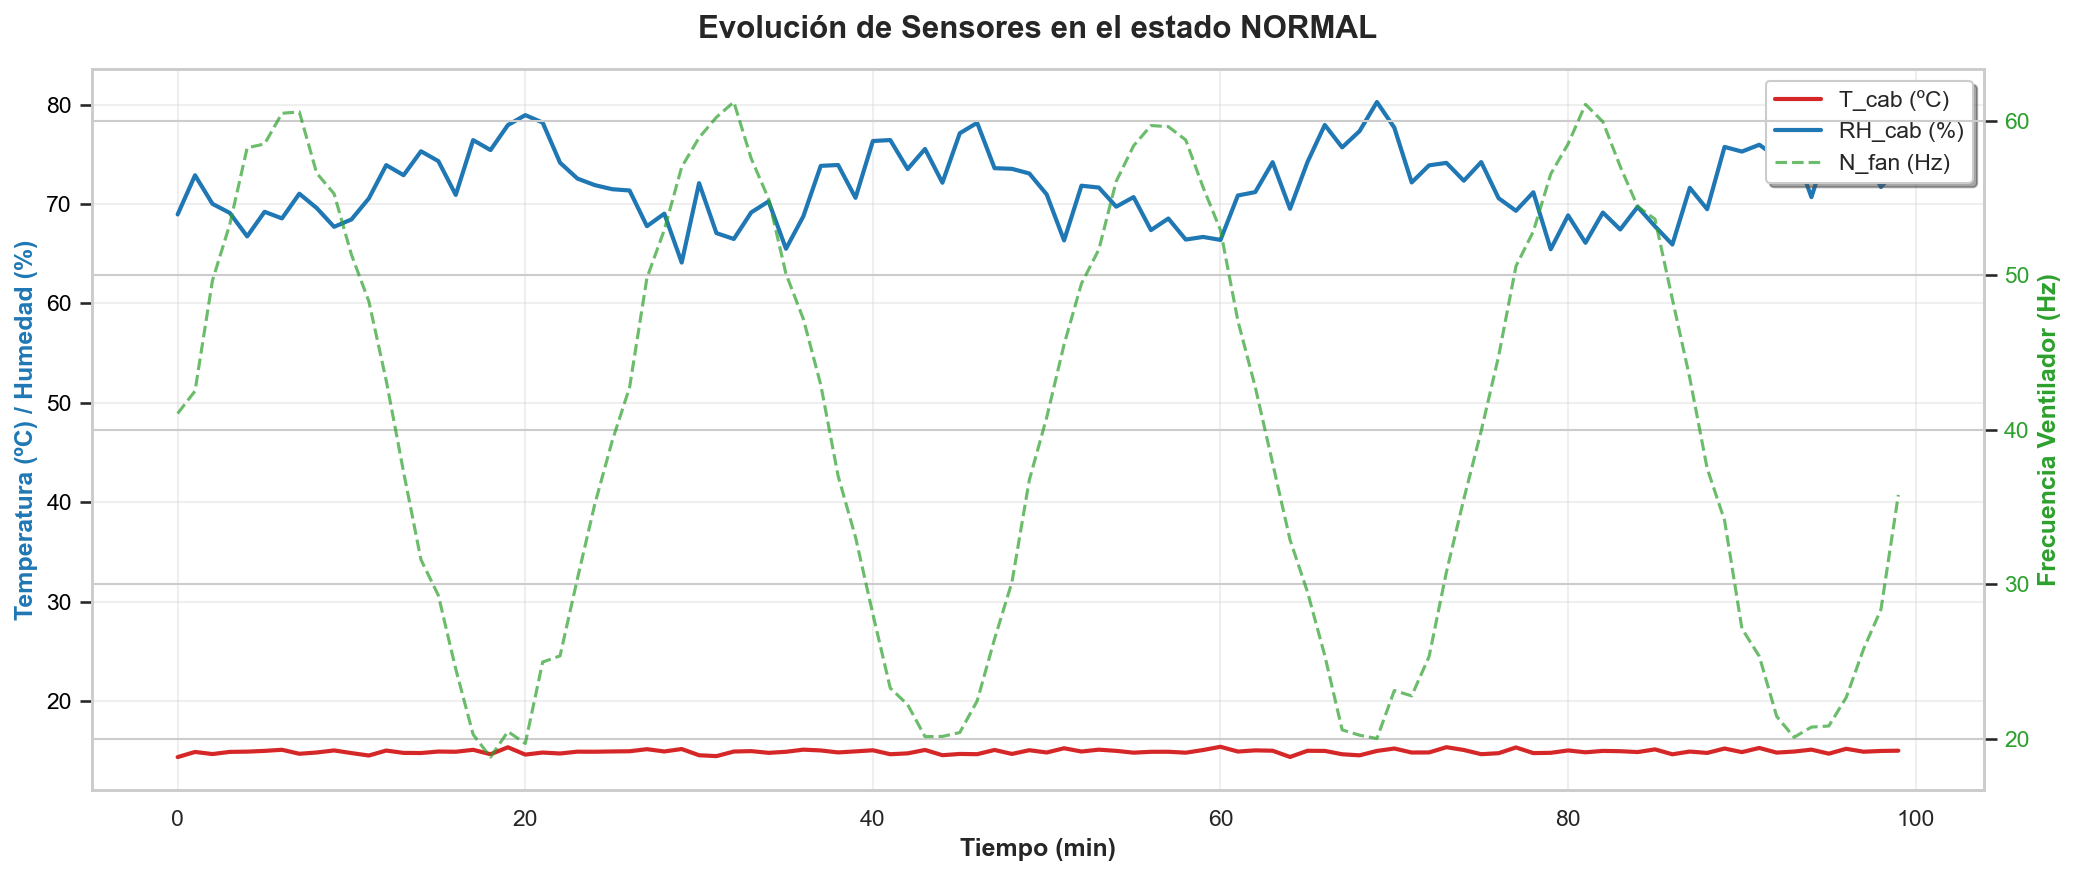

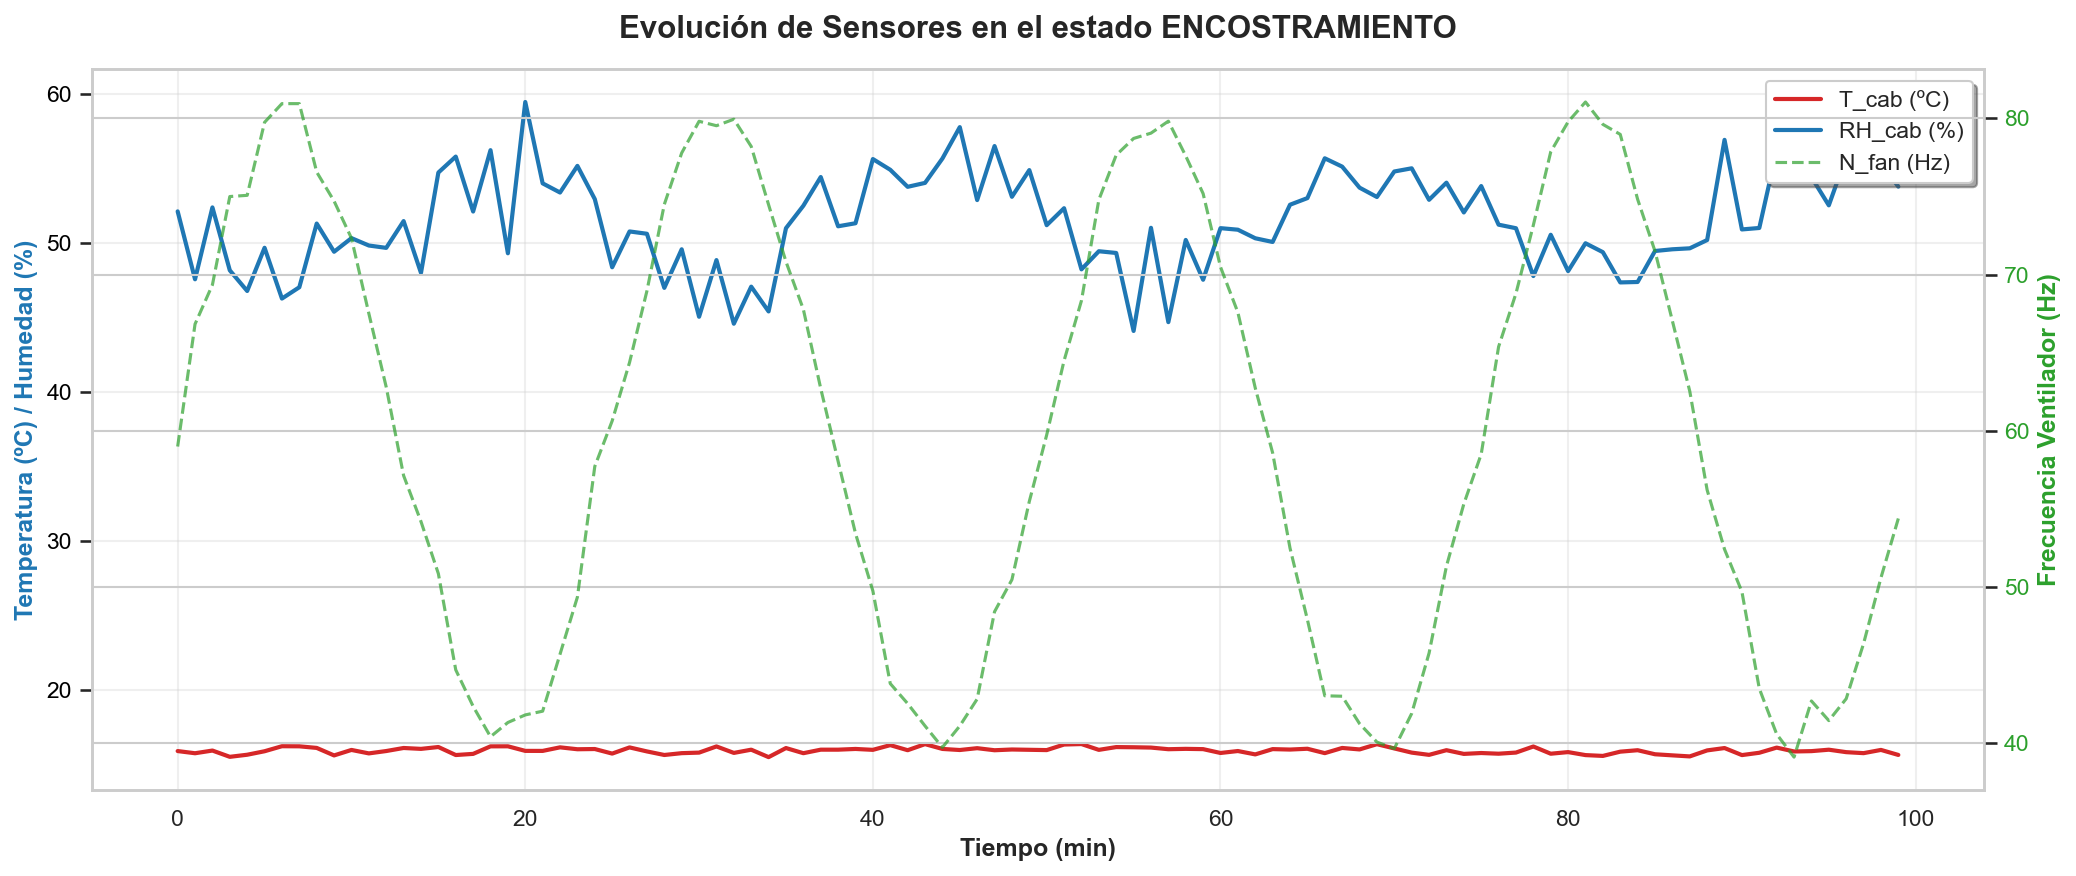

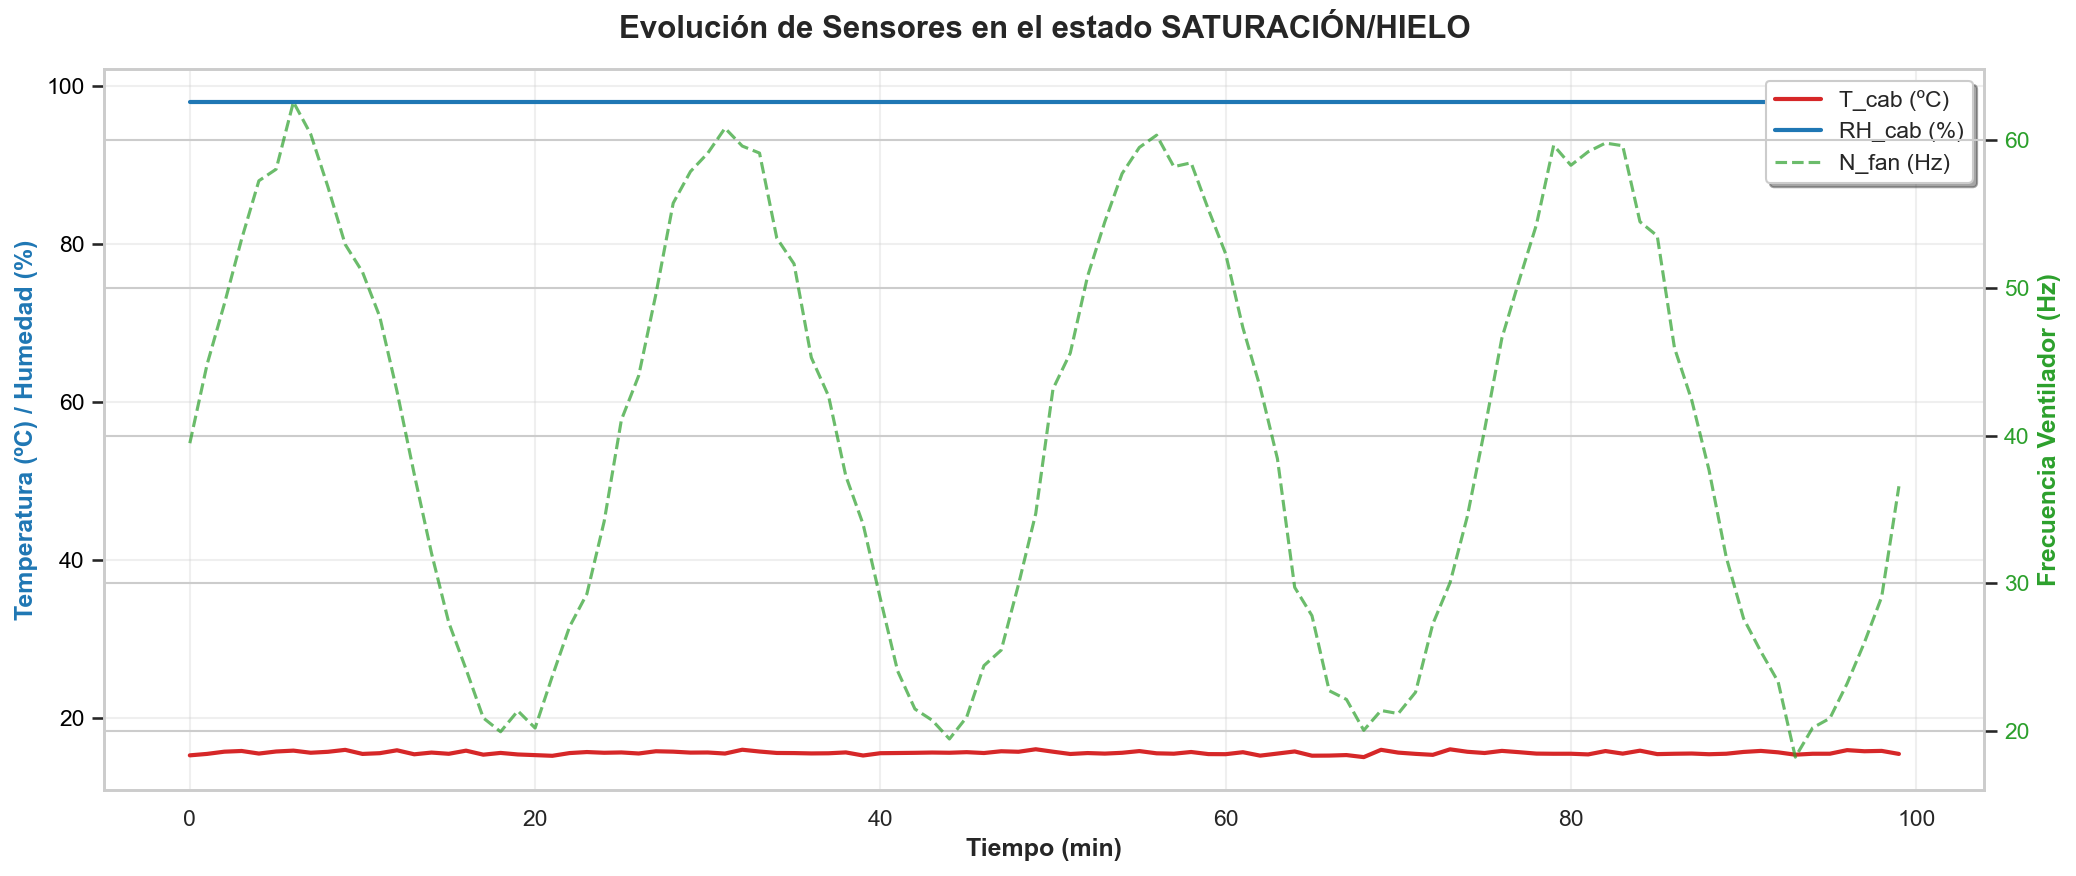

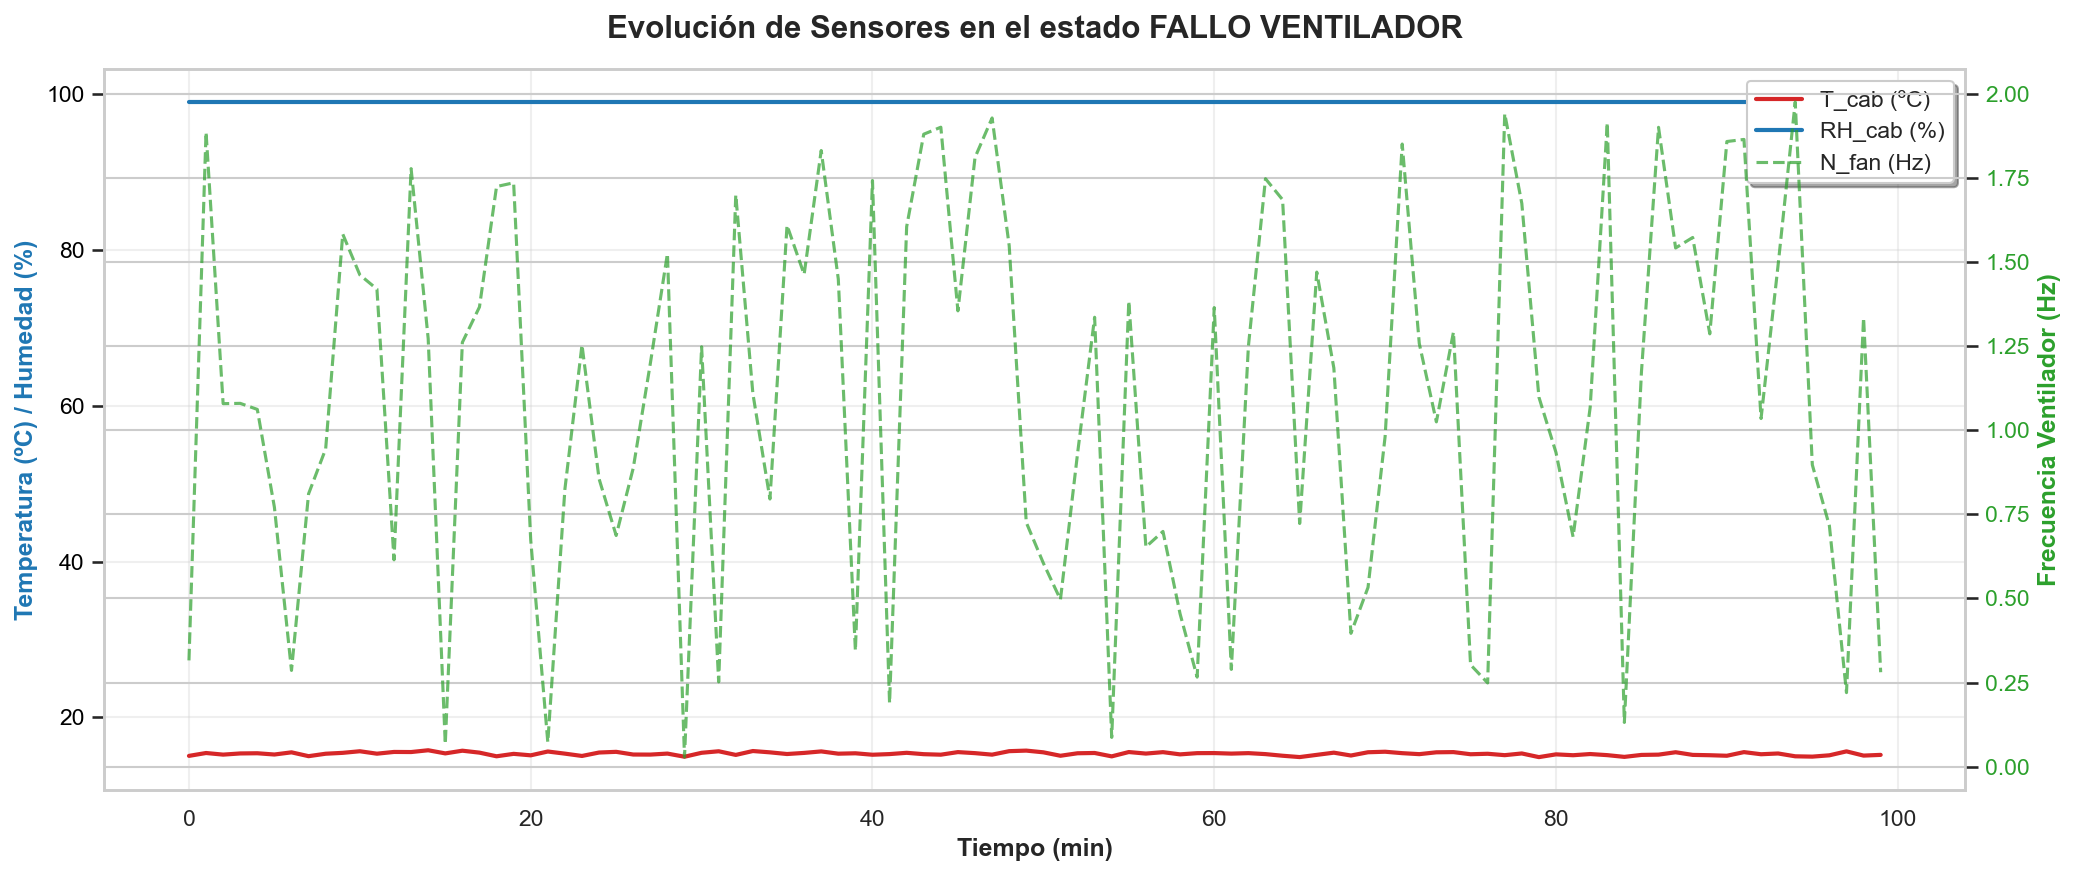

In [3]:
target_names = ['NORMAL', 'ENCOSTRAMIENTO', 'SATURACIÓN/HIELO', 'FALLO VENTILADOR']

for i in range(0,4):
    run_ejemplo = df_raw['run_id'].unique()[i]
    df_run = df_raw[df_raw['run_id'] == run_ejemplo]

    fig, ax1 = plt.subplots(figsize=(14, 6))


    ax1.set_xlabel('Tiempo (min)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Temperatura (ºC) / Humedad (%)', fontsize=12, color='tab:blue', fontweight='bold')
    ax1.plot(df_run['time_min'], df_run['T_cab'], label='T_cab (ºC)', color='tab:red', linewidth=2)
    ax1.plot(df_run['time_min'], df_run['RH_cab'], label='RH_cab (%)', color='tab:blue', linewidth=2)
    ax1.tick_params(axis='y', labelcolor='black')


    ax2 = ax1.twinx()
    ax2.set_ylabel('Frecuencia Ventilador (Hz)', fontsize=12, color='tab:green', fontweight='bold')
    ax2.plot(df_run['time_min'], df_run['N_fan_Hz'], label='N_fan (Hz)', color='tab:green', linestyle='--', alpha=0.7)
    ax2.tick_params(axis='y', labelcolor='tab:green')


    falla_id = df_run['fault_id'].iloc[0]
    plt.title(f'Evolución de Sensores en el estado {target_names[falla_id]}', 
          fontsize=15, fontweight='bold', pad=15)


    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines + lines2, labels + labels2, loc='upper right', frameon=True, shadow=True)

    ax1.grid(True, alpha=0.3)
    plt.tight_layout()

plt.show()



Se confirma que las fallas tienen firmas temporales distintivas. Por ejemplo, en el estado de 'ENCOSTRAMIENTO', la humedad relativa fluctúa a niveles críticos en torno al 55-60%, cuando el ideal debería de ser de 75%. Esto causa una evaporación excesiva en la superficie del producto.

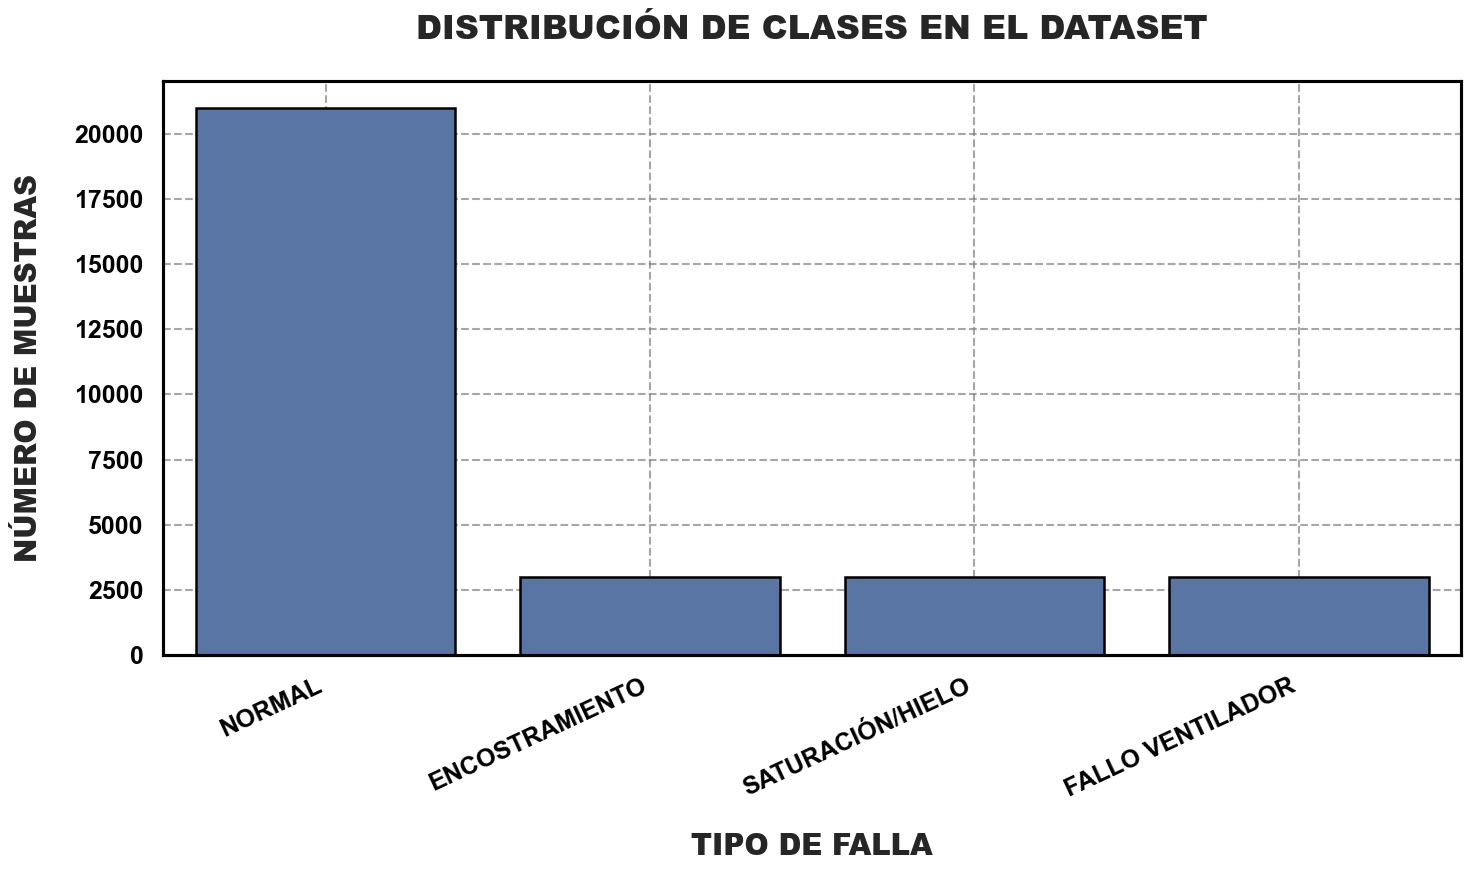

In [4]:
#DISTRIBUCIÓN DE CLASES

plt.figure(figsize=(10, 6))


# Crear el gráfico de barras
ax = sns.countplot(
    data=df_raw, 
    x='fault_id', 
    edgecolor='black', 
    linewidth=1.2
)

# Configuración estética y marco
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(1.5)

ax.set_xticks(range(len(target_names)))
ax.set_xticklabels(target_names, rotation=25, ha='right', fontsize=12, fontweight='bold', color='black')
plt.yticks(fontsize=12, fontweight='bold', color='black')

ax.set_xlabel('TIPO DE FALLA', fontsize=14, fontweight='black', labelpad=15)
ax.set_ylabel('NÚMERO DE MUESTRAS', fontsize=14, fontweight='black', labelpad=15)
plt.title('DISTRIBUCIÓN DE CLASES EN EL DATASET', fontsize=16, fontweight='black', pad=20)

ax.grid(True, linestyle='--', alpha=0.7, color='gray')
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

El dataset presenta un desbalanceo moderado (70% Normal vs 10% por cada tipo de falla). Esto confirma la necesidad de utilizar métricas como el F1-Score Macro en lugar del Accuracy simple, para no ignorar el rendimiento en las clases minoritarias

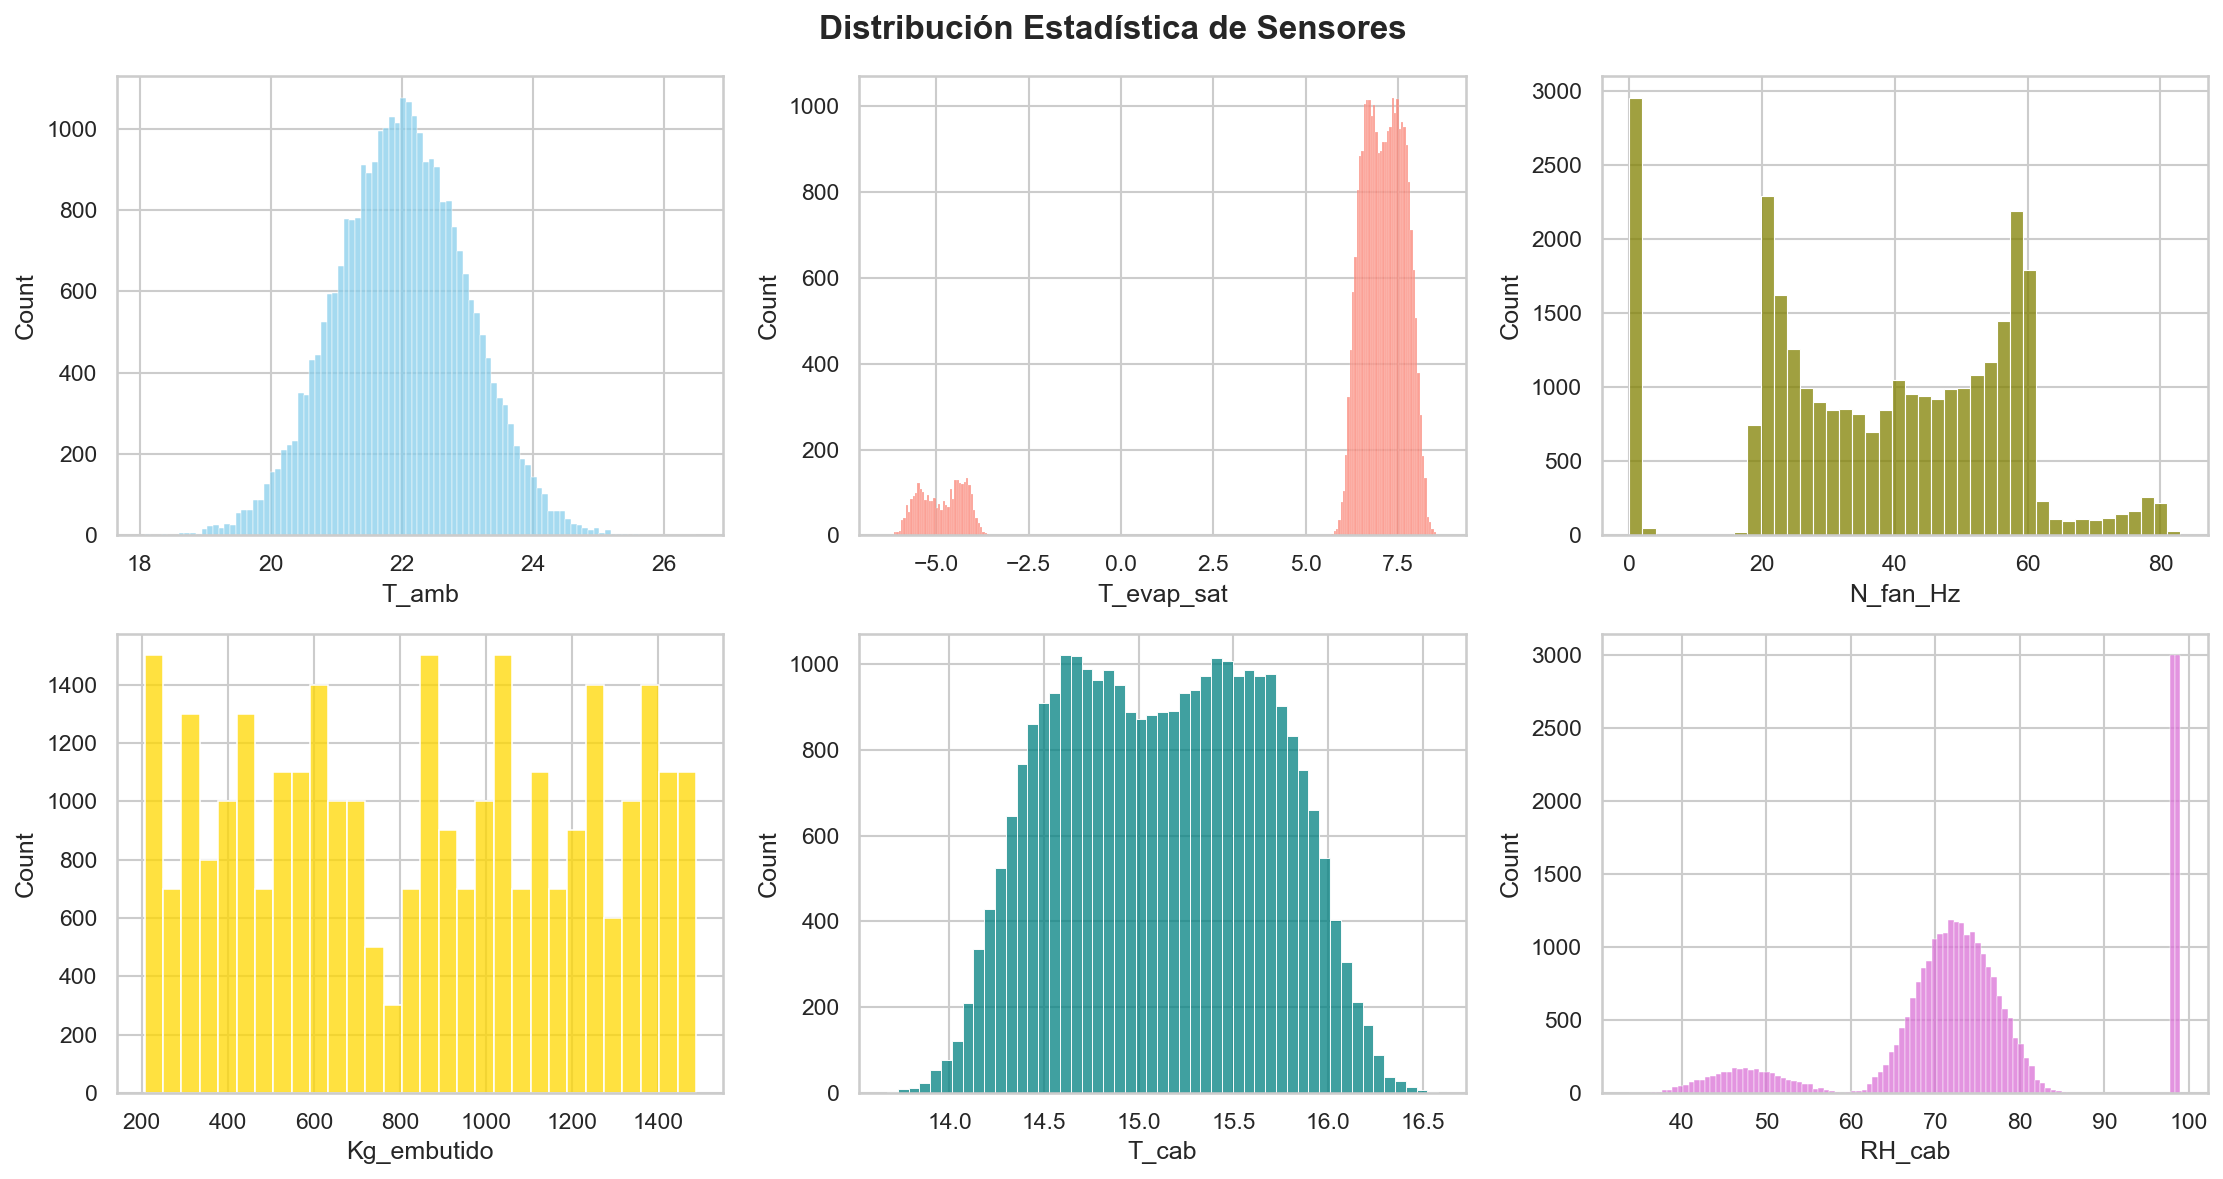

In [5]:
# Distribución de características principales mediante histogramas
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
sns.histplot(data=df_raw, x='T_amb', ax=axes[0, 0], color='skyblue')
sns.histplot(data=df_raw, x='T_evap_sat', ax=axes[0, 1], color='salmon')
sns.histplot(data=df_raw, x='N_fan_Hz', ax=axes[0, 2], color='olive')
sns.histplot(data=df_raw, x='Kg_embutido', ax=axes[1, 0], color='gold')
sns.histplot(data=df_raw, x='T_cab', ax=axes[1, 1], color='teal')
sns.histplot(data=df_raw, x='RH_cab',ax=axes[1, 2], color='orchid')

plt.suptitle('Distribución Estadística de Sensores', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

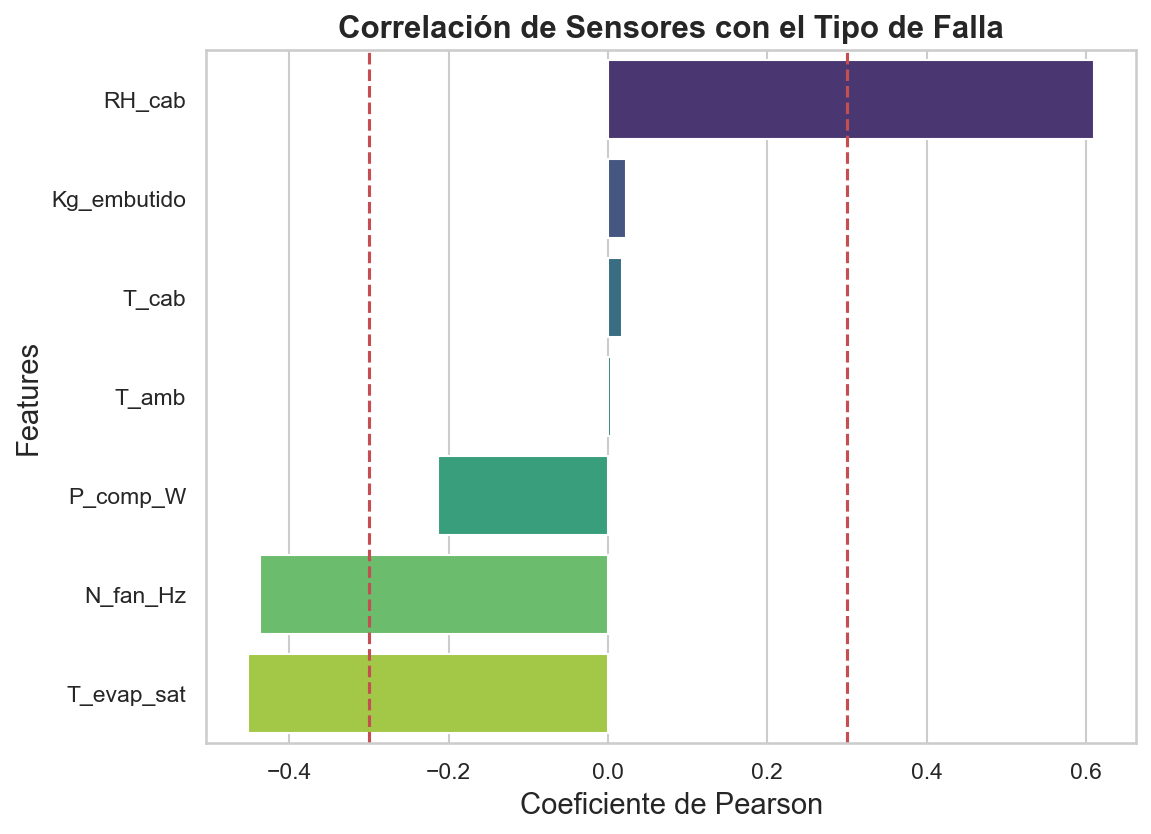

Ranking de Correlación:
RH_cab         0.609926
Kg_embutido    0.023078
T_cab          0.018042
T_amb          0.003883
P_comp_W      -0.212832
N_fan_Hz      -0.436453
T_evap_sat    -0.451244
Name: fault_id, dtype: float64


In [6]:
# Matriz de correlación
corr_matrix = df_raw.select_dtypes(include='number').corr()


fault_corr = corr_matrix['fault_id'].drop(['fault_id', 'run_id', 'T_set', 'time_min'], errors='ignore').sort_values(ascending=False)

# Visualización del Ranking
plt.figure(figsize=(8, 6))
ax = sns.barplot(x=fault_corr.values, y=fault_corr.index, hue=fault_corr.index, palette='viridis', legend=False)

ax.set_xlabel('Coeficiente de Pearson', fontsize=14)
ax.set_ylabel('Features', fontsize=14)
plt.title('Correlación de Sensores con el Tipo de Falla', fontsize=15, fontweight='bold')

plt.axvline(x=0.3, color='r', linestyle='--', label='Umbral de importancia')
plt.axvline(x=-0.3, color='r', linestyle='--')
plt.show()

print("Ranking de Correlación:")
print(fault_corr)

Se identifica que variables como RH_cab tienen una correlación directa alta con el fault_id (>0.60). Sin embargo, otras relaciones son débiles, lo que justifica la creación de variables mediante ingeniería de características (VPD, RH_error) para capturar interacciones no lineales entre temperatura y humedad

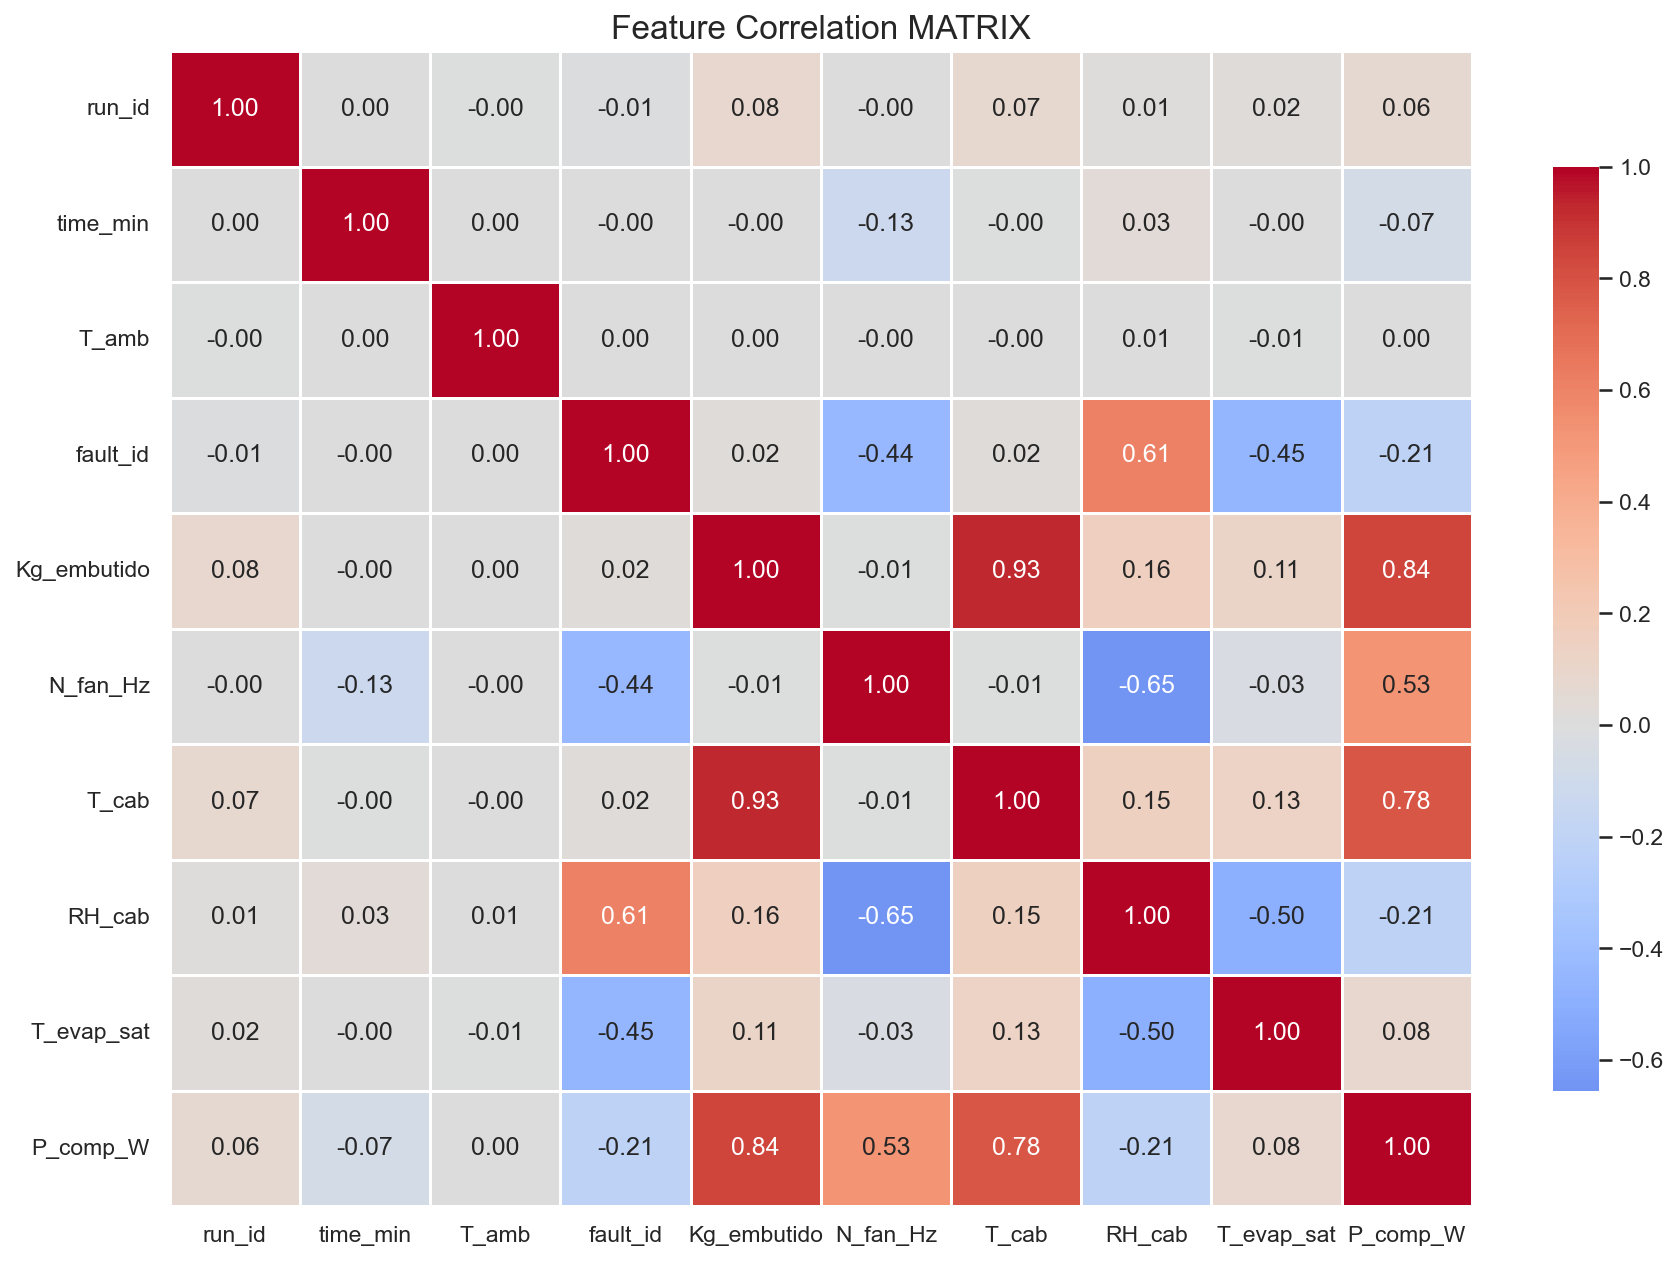

In [7]:
plt.figure(figsize=(14, 10))
core_cols = df_raw.select_dtypes(include='number').columns.drop('T_set') #T_set no tiene ninguna relación con ninguna otra feature (es constante)
corr = df_raw[core_cols].corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0, 
            linewidths=.5, cbar_kws={"shrink": .8})
plt.title('Feature Correlation MATRIX', fontsize=16)
plt.show()

In [8]:
def calculate_vpd(T, RH):
    # Presión de saturación (Fórmula de Tetens)
    es = 0.61078 * np.exp((17.27 * T)/(T + 237.3))
    # Presión real
    ea = es * (RH / 100)
    return es - ea

df_raw['VPD'] = calculate_vpd(df_raw['T_cab'], df_raw['RH_cab'])

#  Ingeniería de Características (Feature Engineering)

Transformamos las señales de los sensores en **indicadores físicos** para capturar la termodinámica del proceso de secado.

---

###  Indicadores Termodinámicos y de Carga
Introducimos las siguientes variables (basadas en la literatura):

* **`RH_error`**: Desviación respecto al set-point ideal (75%). *(Ruiz-Ramírez, 2005)*.
* **`Evap_Eff_Index`**: Relación entre el diferencial de temperatura y la humedad. Vital para detectar **Saturación/Hielo**. *(Andrés et al., 2007)*.
* **`Air_Flow_Ratio`**: Evalúa si el caudal de aire es suficiente para la carga de producto. *(Imre, 1974)*.
* **`Specific_Power_Load`**: Consumo energético normalizado por kilogramo de embutido. *(Toldrá, 2006)*.
* **`VPD`**: Mide la diferencia entre la cantidad de humedad que el aire puede retener cuando está saturado y la cantidad de humedad que realmente contiene, implementado mediante la **Fórmula de Tetens**.



---

###  Detección de Fallas Críticas
Utilizamos el indicador **`Encostramiento_Risk`** para identificar de forma precoz la falla de **Case Hardening** (Falla 1).

Lógica: Una alta frecuencia del ventilador (N_fan) combinada con una baja humedad relativa (RH_cab) acelera la evaporación superficial por encima de la difusión interna de agua, provocando el encostramiento.
</div>


In [9]:
#FUNCION PARA INGENIERÍA DE CARACTERISTICAS
def extract_aireado_features(df):
    
    df_ext = df.copy()
    
    # 1. Delta Higroscópico (Referencia: Ruiz-Ramirez, 2005)
    # Diferencia respecto a la humedad de equilibrio teórica
    df_ext['RH_error'] = df_ext['RH_cab'] - 75.0 
    
    # 2. Ratio Aire/Carga (Referencia: Imre, 1974)
    # Evalúa si el flujo de aire es suficiente para la masa de embutido
    df_ext['Air_Flow_Ratio'] = df_ext['N_fan_Hz'] / (df_ext['Kg_embutido'] + 1.0)
    
    # 3. Eficiencia de Evaporación (Referencia: Andrés et al., 2007)
    # Relación entre enfriamiento y deshumidificación
    df_ext['Evap_Eff_Index'] = (df_ext['T_cab'] - df_ext['T_evap_sat']) / (df_ext['RH_cab'] + 0.1)
    
    # 4. Potencia Específica por Carga (Referencia: Toldrá, 2006)
    # Energía consumida por cada Kg de producto fresco
    df_ext['Specific_Power_Load'] = df_ext['P_comp_W'] / (df_ext['Kg_embutido'] + 1.0)
    
    # 5. Indicador de Encostramiento (Predictor de Falla 1)
    # Aire alto + RH baja = Riesgo de Case Hardening
    df_ext['Encostramiento_Risk'] = df_ext['N_fan_Hz'] / (df_ext['RH_cab'] + 1.0)

    return df_ext

df_phys = extract_aireado_features(df_raw)

<h2> Dinámica Temporal y Lags </h2>
Se han implementado Variables de Retraso (Lags) y Tendencias (Deltas):

Lags (10, 30, 60 min): Permiten al modelo recordar el estado anterior del sistema.

Deltas: Calculan la velocidad de cambio (ej. ¿está bajando la humedad más rápido de lo normal?).

Rolling Mean (Media Móvil): Suaviza el ruido de los sensores para detectar la tendencia de fondo del secado.

In [10]:
#FUNCIÓN PARA CREAR LAGS
def create_aireado_lags(df, features, lags):
    df_lagged = df.copy()
    for feat in features:
        for lag in lags:
            # Valor previo
            df_lagged[f"{feat}_lag_{lag}"] = df_lagged.groupby("run_id")[feat].shift(lag)
            # TENDENCIA: Delta de cambio
            df_lagged[f"{feat}_delta_{lag}"] = df_lagged[feat] - df_lagged[f"{feat}_lag_{lag}"]
    
    # Suavizado de ciclos mediante Rolling Mean
    df_lagged['RH_roll_mean_20'] = df_lagged.groupby('run_id')['RH_cab'].transform(lambda x: x.rolling(20, min_periods=5).mean())
    
    return df_lagged

# Variables críticas para el análisis temporal
features_to_lag = ['RH_cab', 'T_cab', 'N_fan_Hz', 'Evap_Eff_Index']
lags_aireado = [10, 30, 60]

df_final = create_aireado_lags(df_phys, features_to_lag, lags_aireado)

# Eliminación de filas incompletas tras generar lags
df_final = df_final.dropna()
print(f"Dataset procesado final: {df_final.shape}")

Dataset procesado final: (12000, 42)


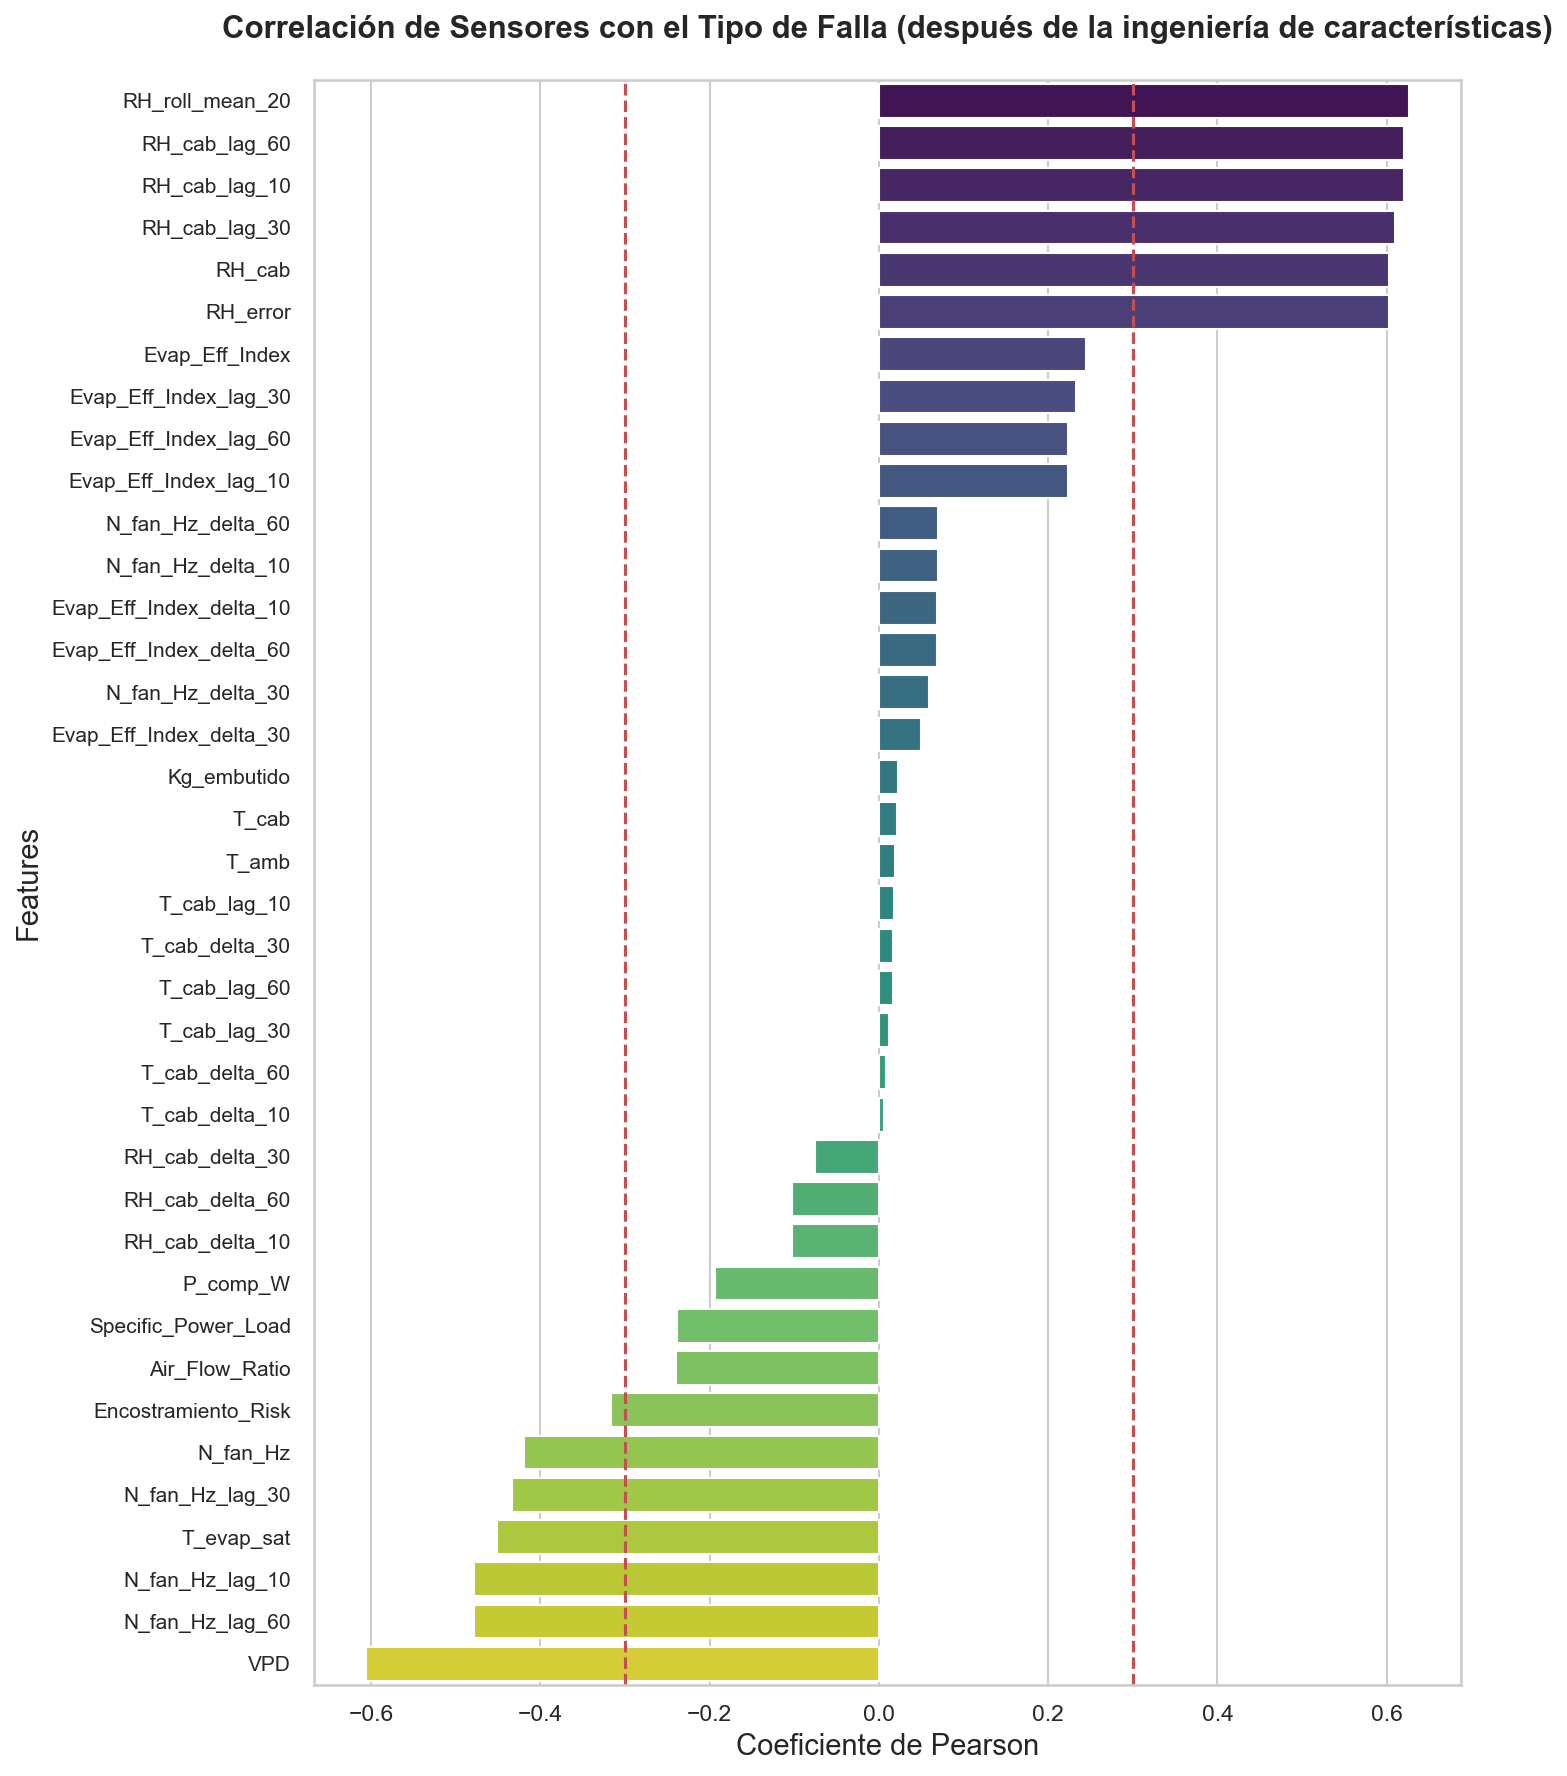

In [11]:
# Matriz de correlación
corr_matrix = df_final.select_dtypes(include='number').corr()

fault_corr = corr_matrix['fault_id'].drop(['fault_id', 'run_id', 'T_set', 'time_min'], errors='ignore').sort_values(ascending=False)

# 1. Aumentamos el alto de la figura (de 6 a 12 para dar aire)
plt.figure(figsize=(10, 12)) 

ax = sns.barplot(x=fault_corr.values, y=fault_corr.index, hue=fault_corr.index, palette='viridis', legend=False)

# 2. Ajustamos el tamaño de los ticks del eje Y y añadimos un pequeño padding
ax.tick_params(axis='y', labelsize=10, pad=5)

ax.set_xlabel('Coeficiente de Pearson', fontsize=14)
ax.set_ylabel('Features', fontsize=14)
plt.title('Correlación de Sensores con el Tipo de Falla (después de la ingeniería de características)', 
          fontsize=15, fontweight='bold', pad=20)

plt.axvline(x=0.3, color='r', linestyle='--', label='Umbral de importancia')
plt.axvline(x=-0.3, color='r', linestyle='--')

# 3. Tight layout ayuda a que no se corten las etiquetas al guardar o mostrar
plt.tight_layout()
plt.show()

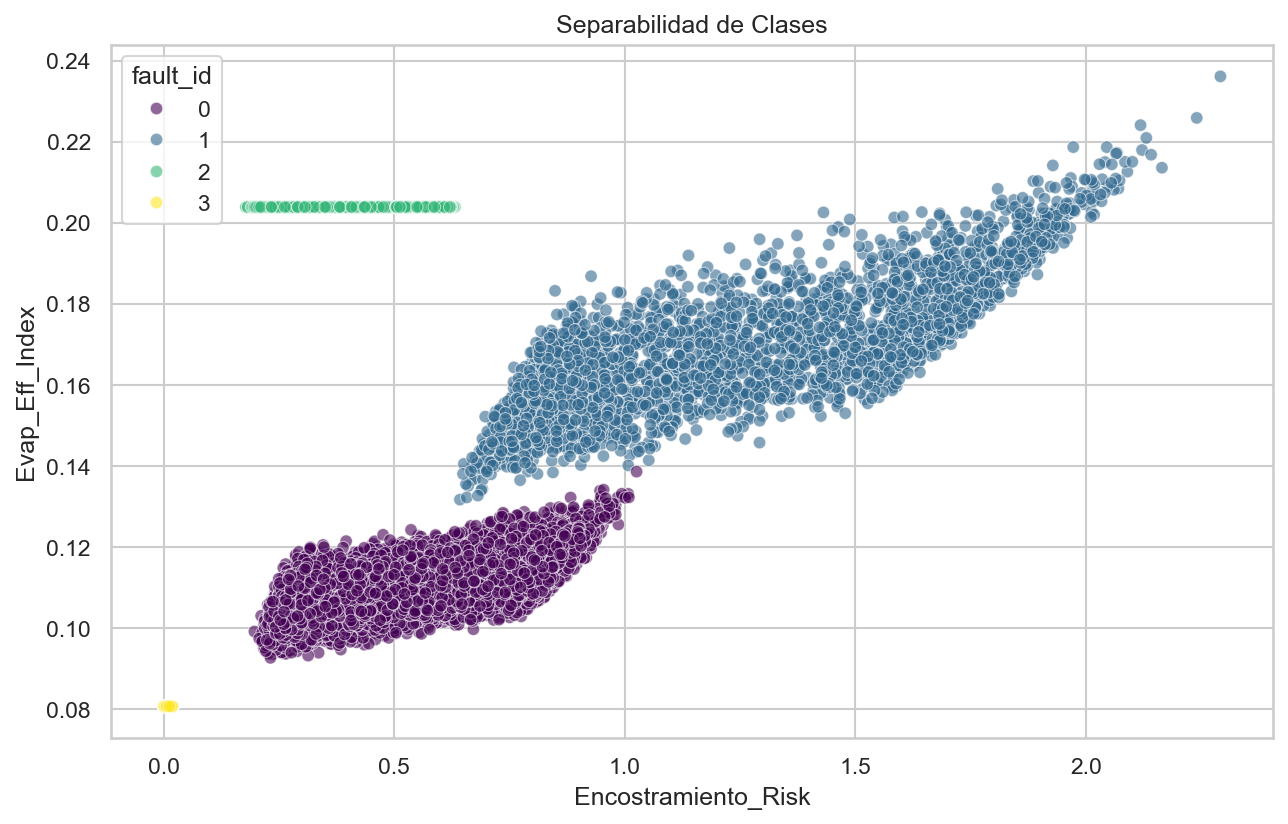

In [12]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_phys, x='Encostramiento_Risk', y='Evap_Eff_Index', 
                hue='fault_id', palette='viridis', alpha=0.6)
plt.title('Separabilidad de Clases')
plt.show()

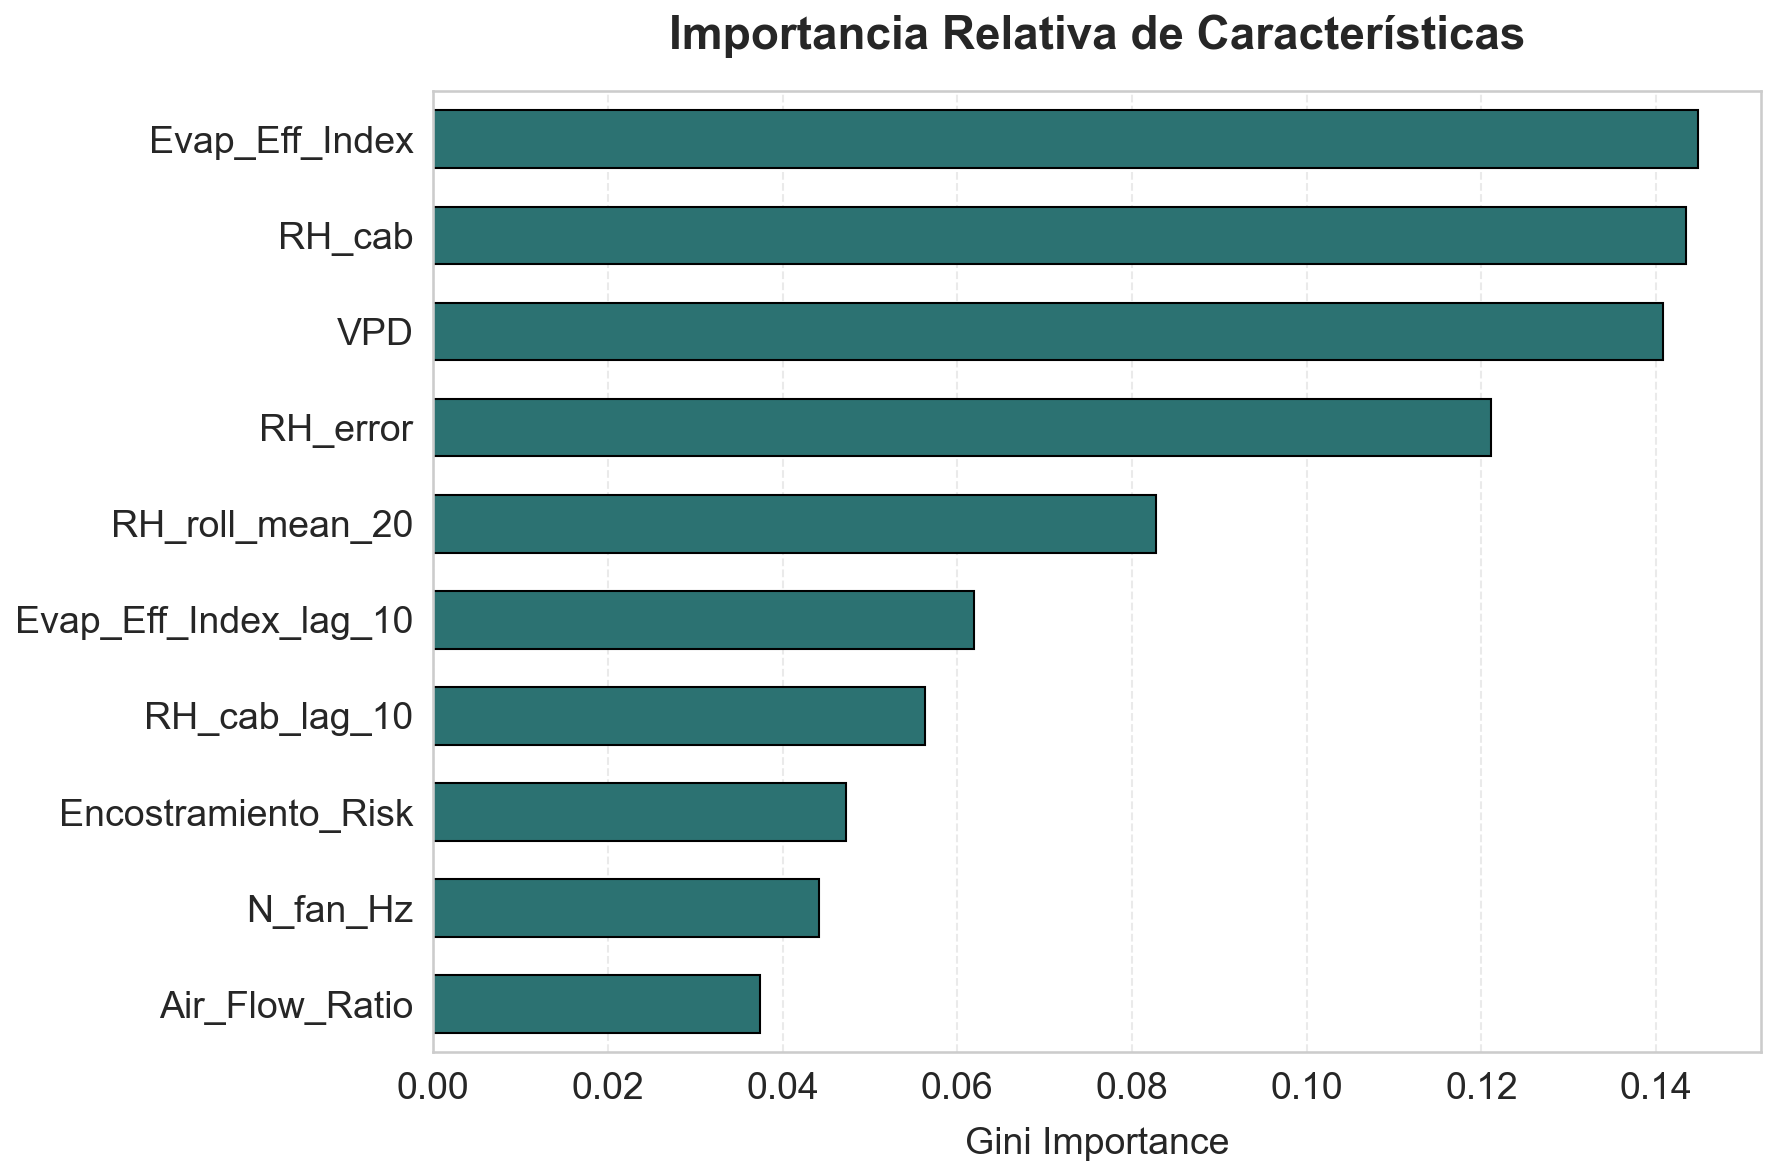

In [20]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

 #FEATURE IMPORTANCE DEL MODELO (Gini Importance) - IMPORTANTE: ESTE CÓDIGO ASUME QUE EL MODELO YA FUE ENTRENADO Y GUARDADO EN LA RUTA ESPECIFICADA. SI NO, DEBERÁS ENTRENARLO PRIMERO O AJUSTAR LA RUTA.

model = joblib.load('../../models/artifacts/aireado_model.pkl')


feature_importances = model.feature_importances_
feature_names = model.feature_names_in_ 

importance_df = pd.DataFrame({'feature': feature_names, 'importance': feature_importances})
importance_df = importance_df.sort_values(by='importance', ascending=False)

plt.figure(figsize=(12, 8)) 


ax = sns.barplot(
    x=importance_df['importance'].head(10), 
    y=importance_df['feature'].head(10), 
    color='#207d7e',  
    edgecolor='black',
    width=0.6  
)


plt.title('Importancia Relativa de Características', fontsize=22, pad=20, fontweight='bold')
plt.xlabel('Gini Importance', fontsize=18, labelpad=10)
plt.ylabel('', fontsize=18)


plt.xticks(fontsize=18)
plt.yticks(fontsize=18)


plt.grid(axis='x', linestyle='--', alpha=0.4)


plt.tight_layout()

plt.show()

Tras introducir las variables físicas, observamos que los Lags (como RH_cab_lag_10) y deltas temporales suben a los primeros puestos de importancia. Esto valida nuestra hipótesis: el diagnóstico de aireado no depende solo de la foto instantánea, sino de la trayectoria histórica del proceso.

In [14]:
# Ruta de salida
output_dir = '../../data/processed/'
output_file = 'dataset_aireado_processed.csv'

# Crear directorio si no existe
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Guardar CSV
df_final.to_csv(os.path.join(output_dir, output_file), index=False)
print(f"Archivo exportado en: {os.path.join(output_dir, output_file)}")

Archivo exportado en: ../../data/processed/dataset_aireado_processed.csv
